# Sentiment Analysis Using Machine Learning Models

This project performs **sentiment analysis** on a large dataset of tweets, classifying them into **positive** or **negative** sentiments using multiple machine learning models. The goal is to **compare the performance** of various classifiers and identify the most effective one.

## Project Overview

### 1. Data Preprocessing
- Tweets are cleaned using **regular expressions**.
- Steps include:
  - Converting text to **lowercase**
  - Removing **URLs**, **usernames**, and **emojis**
  - Eliminating **special characters**
  - Reducing **character repetitions**
  - Applying **lemmatization** for word normalisation

### 2. Feature Extraction
- Tweets are transformed into numerical vectors using **TF-IDF Vectorizer**
- Settings:
  - **Unigram and Bigram features**: `ngram_range=(1, 2)`
  - **Maximum features**: 500,000

## Models Trained & Evaluated
- Logistic Regression
- Bernoulli Naive Bayes
- Multinomial Naive Bayes
- Linear Support Vector Classifier (SVC)
- Stochastic Gradient Descent Classifier (SGD)

## Evaluation Metrics
- **Accuracy** on training and test datasets
- **Classification Report**:
  - Precision
  - Recall
  - F1-Score
- **Confusion Matrix**:
  - Visualised using Seaborn heatmaps

## Word Clouds
- Visual representation of the **most frequent words** in:
  - **Positive** tweets
  - **Negative** tweets

## Model Deployment
- Trained models and TF-IDF vectoriser are **saved using `pickle`** for future predictions.

## Prediction Demo
- A simple input interface is provided.
- Uses the **Logistic Regression model** to predict sentiment of **new, user-provided text**.

This notebook gives a full pipeline from raw tweets to a deployed sentiment classifier — suitable for both experimentation and basic real-world use.

In [16]:
#  Utility Libraries
import re
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.stem import WordNetLemmatizer
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report
dataset = pd.read_csv('senti.csv', encoding='ISO-8859-1')
dataset.head(5)

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


## Renaming Columns and Extracting Relevant Data

To make the dataset easier to work with, we perform the following steps:

- **Rename columns** to use meaningful and consistent names.
- **Extract only the necessary fields**, specifically:
  - The **text content** of each tweet
  - The corresponding **sentiment label** (e.g., positive or negative)

These actions streamline the dataset and prepare it for further processing such as cleaning, vectorisation, and model training.

In [17]:
dataset.columns = ['sentiment', 'id', 'date', 'query', 'user', 'text']
text, sentiment = list(dataset['text']), list(dataset['sentiment'])

## Simplifying the Dataset

To focus only on the relevant information for sentiment analysis, we take the following steps:

- **Drop unnecessary columns** that are not useful for text classification.
- **Standardise sentiment values**

This cleanup ensures that the dataset is lean, clear, and optimised for training machine learning models.

In [18]:
dataset = dataset[['sentiment','text']]
dataset['sentiment'] = dataset['sentiment'].replace(4,1)

In [19]:
dataset.head(5)

,sentiment,text
0,0,is upset that he can't update his Facebook by ...
1,0,@Kenichan I dived many times for the ball. Man...
2,0,my whole body feels itchy and like its on fire
3,0,"@nationwideclass no, it's not behaving at all...."
4,0,@Kwesidei not the whole crew


## Plotting Positive vs Negative Tweets

We use **Seaborn** to visualise the distribution of sentiment labels in the dataset.

This plot helps us quickly assess:
- Whether the dataset is **balanced** (similar number of positive and negative tweets), or  
- If it is **skewed** toward one sentiment class

Understanding this distribution is crucial for selecting appropriate evaluation metrics and model strategies.

<Axes: xlabel='sentiment', ylabel='count'>

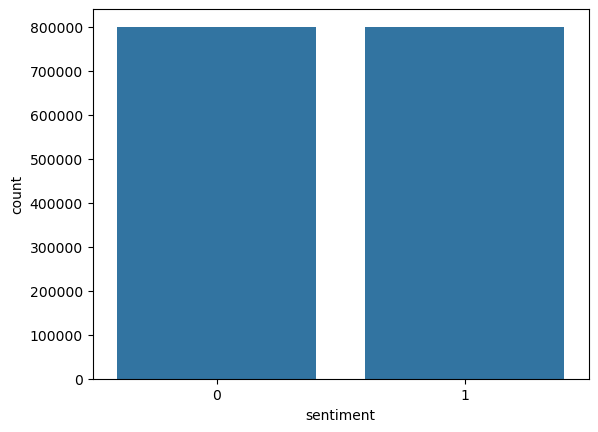

In [20]:
import seaborn as sns
sns.countplot(x='sentiment', data=dataset)

## Emoji Dictionary & Stopword List Setup

Two essential components are prepared for effective text preprocessing:

1. **Emoji Dictionary**  
   A mapping of common emojis and emoticons to their descriptive meanings (e.g., `":)" → "smile"`).  
   This allows the model to better interpret emotional context from symbols.

2. **Stopword List**  
   A list of frequently used English words (e.g., "the", "is", "in") that are typically removed because they carry little semantic weight in sentiment analysis.

Together, these elements help transform raw tweet text into cleaner, more meaningful input for the machine learning pipeline.

In [21]:
# Defining dictionary containing all emojis with their meanings.
emojis = {':)': 'smile', ':-)': 'smile', ';d': 'wink', ':-E': 'vampire', ':(': 'sad',
          ':-(': 'sad', ':-<': 'sad', ':P': 'raspberry', ':O': 'surprised',
          ':-@': 'shocked', ':@': 'shocked',':-$': 'confused', ':\\': 'annoyed',
          ':#': 'mute', ':X': 'mute', ':^)': 'smile', ':-&': 'confused', '$_$': 'greedy',
          '@@': 'eyeroll', ':-!': 'confused', ':-D': 'smile', ':-0': 'yell', 'O.o': 'confused',
          '<(-_-)>': 'robot', 'd[-_-]b': 'dj', ":'-)": 'sadsmile', ';)': 'wink',
          ';-)': 'wink', 'O:-)': 'angel','O*-)': 'angel','(:-D': 'gossip', '=^.^=': 'cat'}

## Defining set containing all stopwords in english.
stopwordlist = ['a', 'about', 'above', 'after', 'again', 'ain', 'all', 'am', 'an',
             'and','any','are', 'as', 'at', 'be', 'because', 'been', 'before',
             'being', 'below', 'between','both', 'by', 'can', 'd', 'did', 'do',
             'does', 'doing', 'down', 'during', 'each','few', 'for', 'from',
             'further', 'had', 'has', 'have', 'having', 'he', 'her', 'here',
             'hers', 'herself', 'him', 'himself', 'his', 'how', 'i', 'if', 'in',
             'into','is', 'it', 'its', 'itself', 'just', 'll', 'm', 'ma',
             'me', 'more', 'most','my', 'myself', 'now', 'o', 'of', 'on', 'once',
             'only', 'or', 'other', 'our', 'ours','ourselves', 'out', 'own', 're',
             's', 'same', 'she', "shes", 'should', "shouldve",'so', 'some', 'such',
             't', 'than', 'that', "thatll", 'the', 'their', 'theirs', 'them',
             'themselves', 'then', 'there', 'these', 'they', 'this', 'those',
             'through', 'to', 'too','under', 'until', 'up', 've', 'very', 'was',
             'we', 'were', 'what', 'when', 'where','which','while', 'who', 'whom',
             'why', 'will', 'with', 'won', 'y', 'you', "youd","youll", "youre",
             "youve", 'your', 'yours', 'yourself', 'yourselves']

## Preprocessing Function for Tweets

We define a custom function to clean and normalise raw tweet text. The function performs the following steps:

- **Lowercasing**  
  Converts all text to lowercase to ensure uniformity.

- **URL Replacement**  
  Replaces links with a placeholder token like `'URL'`.

- **Emoji Translation**  
  Uses the emoji dictionary to replace symbols with their corresponding descriptions.

- **Username Replacement**  
  Replaces Twitter handles (e.g., `@user`) with the token `'USER'`.

- **Special Character Removal**  
  Removes non-alphanumeric characters to simplify the text.

- **Character Repetition Reduction**  
  Reduces elongated words (e.g., `"soooo"` → `"soo"`).

- **Lemmatization**  
  Converts words to their base form (e.g., `"running"` → `"run"`).

- **Negation Handling**  
  Handling negations by appending a suffix to words following negation words.

This function prepares the tweet data for vectorisation and model training.

In [22]:
def preprocess(textdata):
    processedText = []

    # Create Lemmatizer
    from nltk.stem import WordNetLemmatizer
    wordLemm = WordNetLemmatizer()

    # Define regex patterns
    urlPattern = r"((http://)[^ ]*|(https://)[^ ]*|( www\.)[^ ]*)"
    userPattern = r'@[^\s]+'
    alphaPattern = r"[^a-zA-Z0-9]"
    sequencePattern = r"(.)\1\1+"
    seqReplacePattern = r"\1\1"

    # Define negation logic
    negation_words = {"not", "no", "never", "n't"}
    negation_suffix = "_NEG"

    for tweet in textdata:
        # Lowercase
        tweet = tweet.lower()

        # Replace URLs
        tweet = re.sub(urlPattern, ' URL', tweet)

        # Emoji Translation
        for emoji in emojis:
            tweet = tweet.replace(emoji, "EMOJI" + emojis[emoji])

        # Replace user mentions
        tweet = re.sub(userPattern, ' USER', tweet)

        # Remove special characters
        tweet = re.sub(alphaPattern, " ", tweet)

        # Reduce repeated characters
        tweet = re.sub(sequencePattern, seqReplacePattern, tweet)

      #  Negation Handling
        negated = False
        negated_words = []
        for word in tweet.split():
            if word in negation_words:
                negated = True
                negated_words.append(word)
            elif negated:
                negated_words.append(word + negation_suffix)
            else:
                negated_words.append(word)

        #    Lemmatization (using NLTK)
        lemmatized_words = []
        for word in negated_words:
            if len(word) > 1:
                lemmatized_words.append(wordLemm.lemmatize(word))

        #Append processed tweet
        processedText.append(" ".join(lemmatized_words))

    return processedText

## Preprocessing Step Explanation

This step initialises the Natural Language Toolkit (NLTK) library and ensures that the **WordNet** corpus is available for lemmatization tasks. WordNet provides a rich lexical database that helps reduce words to their base or root forms. After setting up the environment, the `preprocess(text)` function is called to clean and normalise the raw input text. This function typically performs operations such as tokenisation, converting text to lowercase, removing stopwords, and lemmatization. Finally, a confirmation message is printed to indicate that preprocessing has completed successfully.

In [24]:
import nltk

nltk.download('wordnet')
processedtext = preprocess(text)
print(f'**Done**')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


**Done**


## Before and After Preprocessing

To demonstrate the effect of preprocessing on the dataset, let's compare the **raw tweet text** with the **cleaned text** after preprocessing. This will help visualize how the text data is transformed during the preprocessing steps.

In [25]:
print('Tweet Data Before Preprocessing')
print('-'*100)
for tweet in text[:10]:
    print(tweet)
print('-'*100)

print(' '*5000)
print(' '*5000)

print('Tweet Data After Preprocessing')
print('-'*100)
for tweet in processedtext[:10]:
    print(tweet)
print('-'*100)

Tweet Data Before Preprocessing
----------------------------------------------------------------------------------------------------
is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!
@Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds
my whole body feels itchy and like its on fire 
@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there. 
@Kwesidei not the whole crew 
Need a hug 
@LOLTrish hey  long time no see! Yes.. Rains a bit ,only a bit  LOL , I'm fine thanks , how's you ?
@Tatiana_K nope they didn't have it 
@twittera que me muera ? 
spring break in plain city... it's snowing 
----------------------------------------------------------------------------------------------------
                                                                                                                                                           

## Visualising Negative Tweet Data: Word Cloud

We can create a word cloud for the negative sentiment data to identify the most frequent words. This visualisation helps us understand which terms are commonly associated with negative sentiments

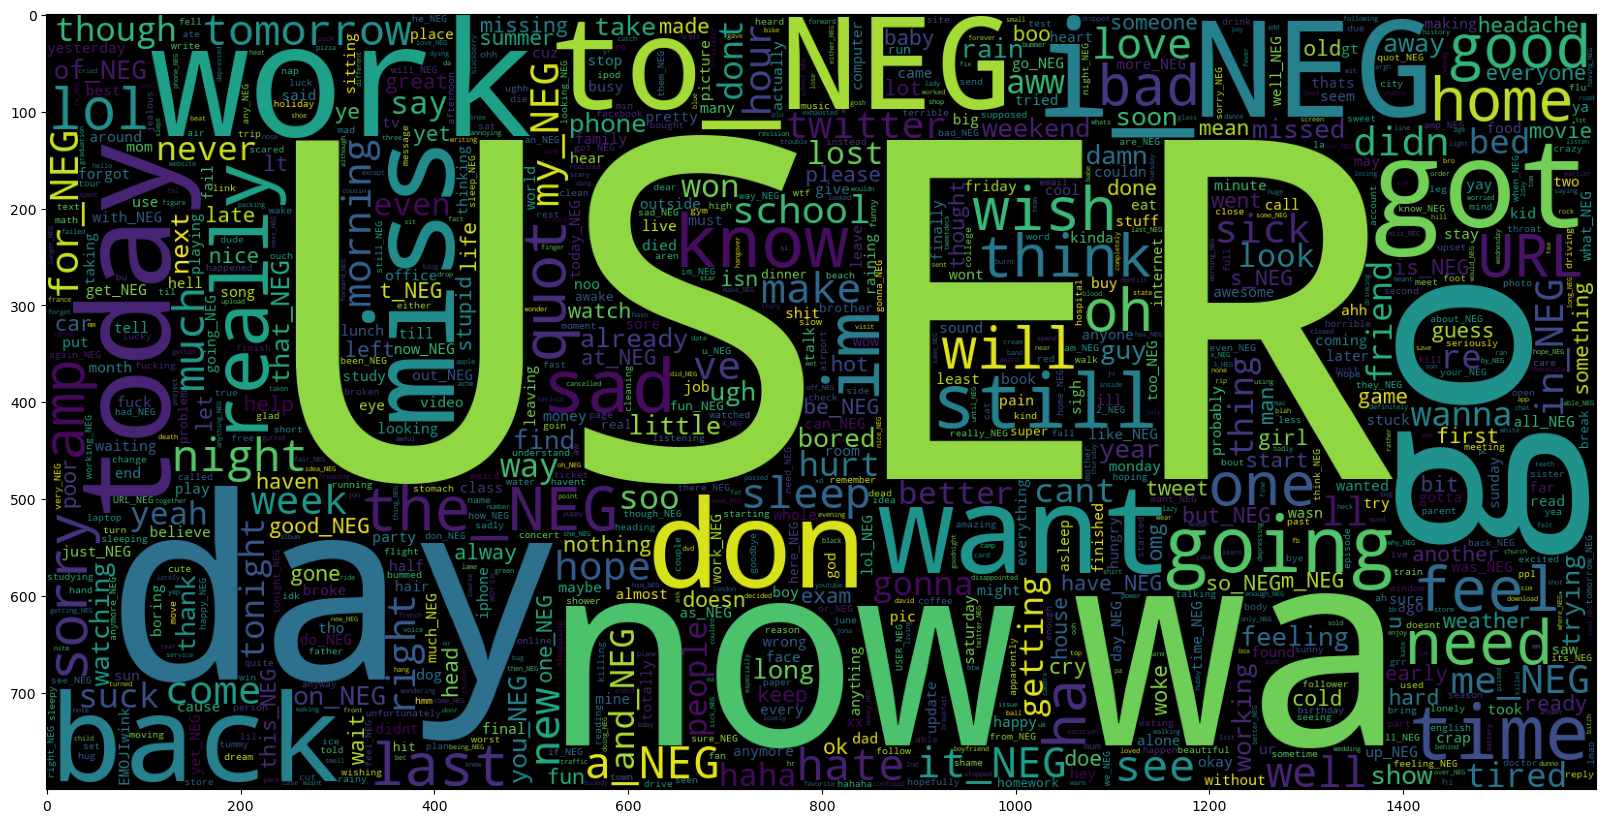

In [26]:
data_neg = processedtext[:800000]
plt.figure(figsize = (20,20))
wc = WordCloud(max_words = 1000 , width = 1600 , height = 800,
               collocations=False).generate(" ".join(data_neg))
plt.imshow(wc)

## Visualising Positive Tweet Data: Word Cloud

We can create a word cloud using the positive sentiment data to identify the most frequently occurring words. This visualisation helps us understand which terms are commonly associated with positive sentiments.

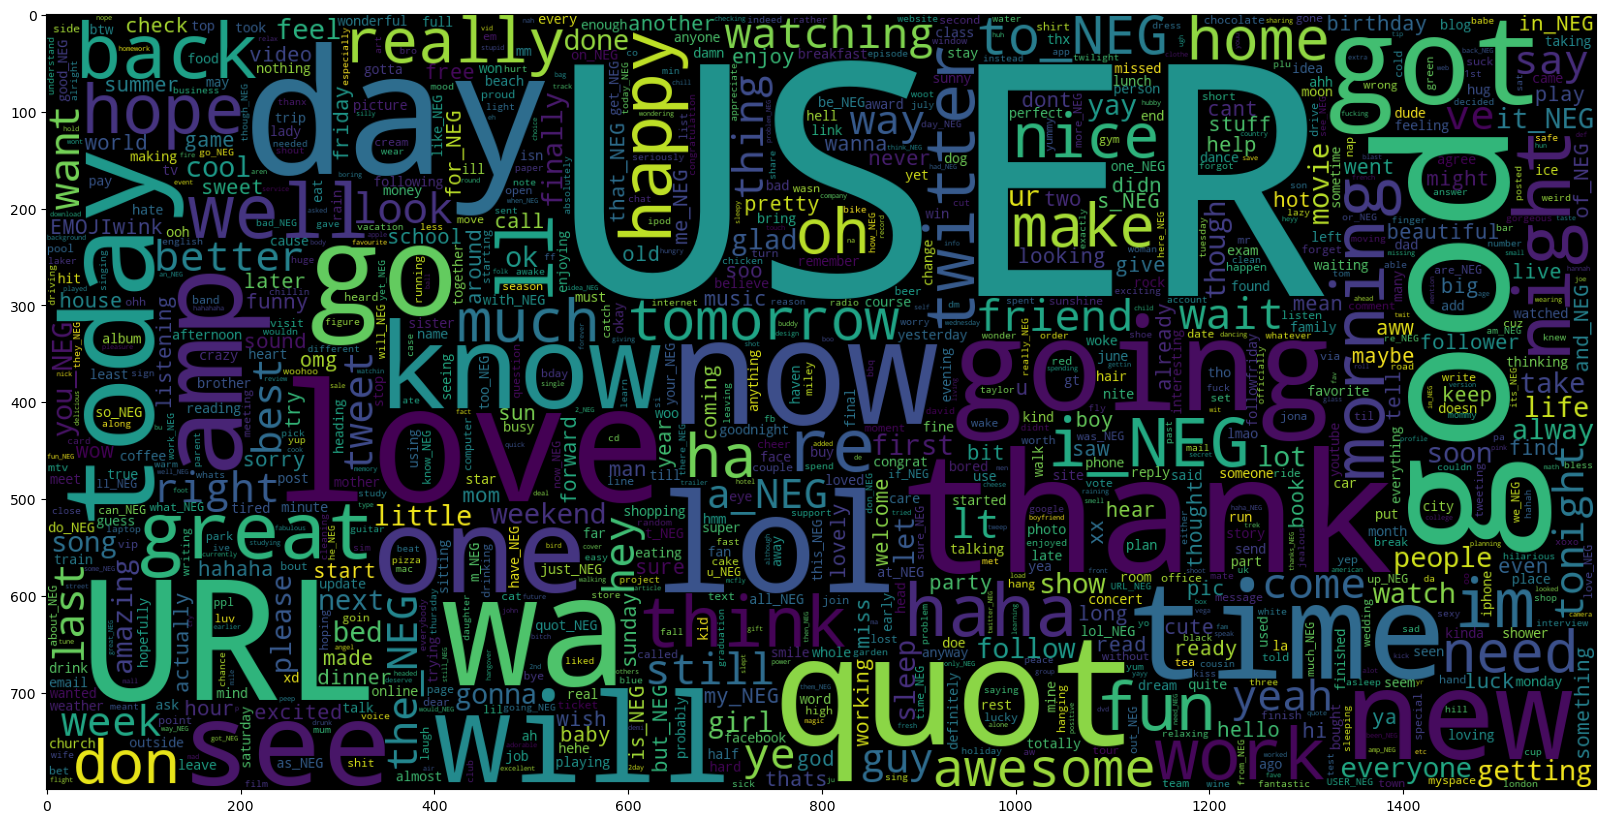

In [27]:
data_pos = processedtext[800000:]
wc = WordCloud(max_words = 1000 , width = 1600 , height = 800,
              collocations=False).generate(" ".join(data_pos))
plt.figure(figsize = (20,20))
plt.imshow(wc)

## Splitting the Data into Training and Testing Sets

To evaluate the performance of our machine learning models, we divide the dataset into two subsets:

- **Training Set (95%)** – Used to train the model
- **Testing Set (5%)** – Used to evaluate model performance on unseen data

This split helps ensure that the model learns patterns from the training data while being tested on a separate set to check generalisation and avoid overfitting.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(processedtext, sentiment,
test_size = 0.05, random_state = 0)

# **Feature Extraction with TF-IDF Vectoriser**

We are using **TF-IDF (Term Frequency-Inverse Document Frequency)** to convert the text data into numerical features that machine learning models can understand. This method helps in identifying **important words** in the text based on their **frequency** and how **unique** they are across all documents.

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectoriser = TfidfVectorizer(ngram_range=(1,2), max_features=500000)
vectoriser.fit(X_train)
print(f'Vectoriser fitted.')
print('No. of feature_words: ', len(vectoriser.get_feature_names_out()))

Vectoriser fitted.
No. of feature_words:  500000


# **Transforming Text Data into TF-IDF Features**

Once the **TF-IDF Vectoriser** is fitted on the training data (`X_train`), we use it to **transform both the training and testing datasets** into numerical feature vectors.

In [31]:
X_train = vectoriser.transform(X_train)
X_test = vectoriser.transform(X_test)

# **Model Evaluation and Confusion Matrix**

The `model_Evaluate` function is designed to **evaluate machine learning models** and **visualise their performance** using:

- **Classification Report:** Shows metrics like **precision, recall, f1-score**, etc.
- **Confusion Matrix:** Visualises how well the model predicted the classes using a **heatmap**.

In [32]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.naive_bayes import BernoulliNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

#  Evaluation function
def model_Evaluate(model, X_test, y_test):
    # Predict text values
    y_pred = model.predict(X_test)

    # classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Compute and plot the Confusion matrix
    cf_matrix = confusion_matrix(y_test, y_pred)
    categories = ['Negative', 'Positive']
    group_names = ['True Neg', 'False Pos', 'False Neg', 'True Pos']

    # Compute percentages
    cf_matrix_percent = cf_matrix / np.sum(cf_matrix) * 100

    # Create labels
    labels = [[f'{group_names[i*2 + j]}\n{cf_matrix_percent[i, j]:.2f}%' for j in range(2)] for i in range(2)]
    labels = np.array(labels)

    # Plot
    sns.heatmap(cf_matrix, annot=labels, cmap='Blues', fmt='', xticklabels=categories, yticklabels=categories)
    plt.xlabel("Predicted values", fontdict={'size': 14}, labelpad=10)
    plt.ylabel("Actual values", fontdict={'size': 14}, labelpad=10)
    plt.title(f"{model.__class__.__name__} - Confusion Matrix", fontdict={'size': 18}, pad=20)
    plt.show()

# **Training and Evaluating the Bernoulli Naive Bayes (BNB) Model**

The following steps outline the process of **training and evaluating the Bernoulli Naive Bayes (BNB) model** using the dataset:

BernoulliNB Results
-----------------------
Training accuracy: 81.7 %
Test accuracy: 79.67 %

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.77      0.79     39986
           4       0.78      0.82      0.80     40014

    accuracy                           0.80     80000
   macro avg       0.80      0.80      0.80     80000
weighted avg       0.80      0.80      0.80     80000



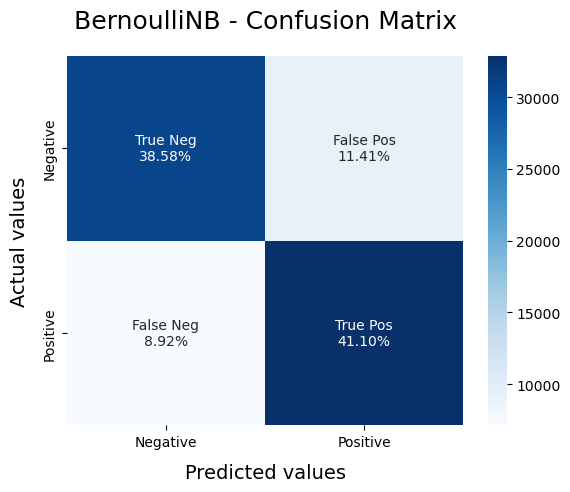

In [33]:
BNBmodel = BernoulliNB(alpha=2)
BNBmodel.fit(X_train, y_train)

train_accuracy = BNBmodel.score(X_train, y_train)
test_accuracy = BNBmodel.score(X_test, y_test)

print('BernoulliNB Results')
print('-----------------------')
print('Training accuracy:', round(train_accuracy * 100, 2), '%')
print('Test accuracy:', round(test_accuracy * 100, 2), '%')

model_Evaluate(BNBmodel, X_test, y_test)

# **Training and Evaluating the LinearSVC Model**

The following steps outline the process of **training and evaluating the Linear Support Vector Classifier (SVC) model** using the dataset:

LinearSVC Results
------------------
Training accuracy: 90.41 %
Test accuracy: 81.48 %

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.81      0.81     39986
           4       0.81      0.82      0.82     40014

    accuracy                           0.81     80000
   macro avg       0.81      0.81      0.81     80000
weighted avg       0.81      0.81      0.81     80000



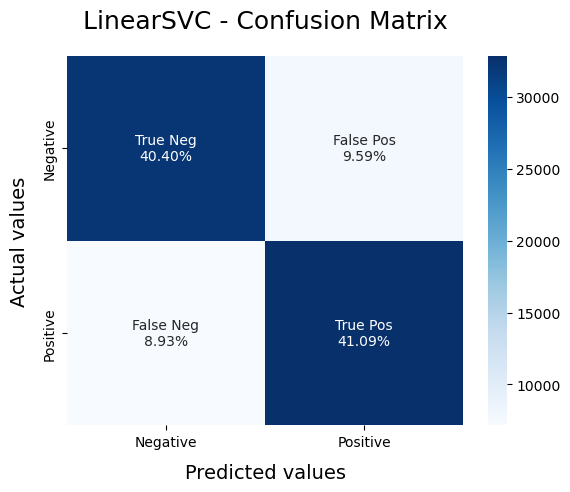

In [34]:
SVCmodel = LinearSVC()
SVCmodel.fit(X_train, y_train)

train_accuracy = SVCmodel.score(X_train, y_train)
test_accuracy = SVCmodel.score(X_test, y_test)

print('LinearSVC Results')
print('------------------')
print('Training accuracy:', round(train_accuracy * 100, 2), '%')
print('Test accuracy:', round(test_accuracy * 100, 2), '%')

model_Evaluate(SVCmodel, X_test, y_test)

# **Training and Evaluating the Logistic Regression Model**

The following steps outline the process of **training and evaluating the Logistic Regression model** using the dataset:

Logistic Regression Results
----------------------------
Training accuracy: 85.0 %
Test accuracy: 82.6 %

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.82      0.82     39986
           4       0.82      0.83      0.83     40014

    accuracy                           0.83     80000
   macro avg       0.83      0.83      0.83     80000
weighted avg       0.83      0.83      0.83     80000



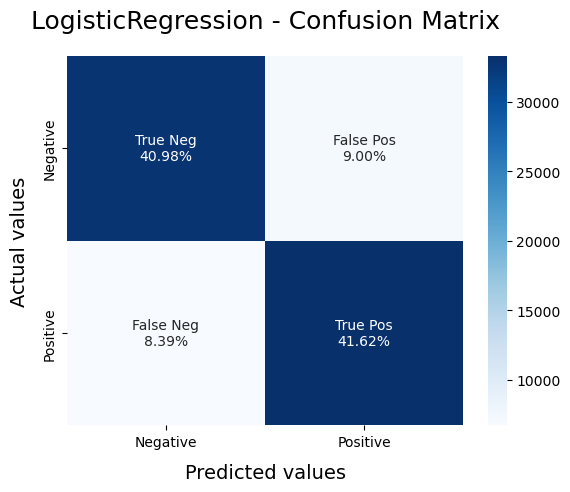

In [35]:
from sklearn.linear_model import LogisticRegression


LRmodel = LogisticRegression(max_iter=1000)
LRmodel.fit(X_train, y_train)

train_accuracy = LRmodel.score(X_train, y_train)
test_accuracy = LRmodel.score(X_test, y_test)

print('Logistic Regression Results')
print('----------------------------')
print('Training accuracy:', round(train_accuracy * 100, 2), '%')
print('Test accuracy:', round(test_accuracy * 100, 2), '%')

model_Evaluate(LRmodel, X_test, y_test)

# **Training and Evaluating the Multinomial Naive Bayes (NB) Model**

The following steps outline the process of **training and evaluating the Multinomial Naive Bayes model** using the dataset:

MultinomialNB Results
----------------------
Training accuracy: 82.97 %
Test accuracy: 80.32 %

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80     39986
           4       0.80      0.80      0.80     40014

    accuracy                           0.80     80000
   macro avg       0.80      0.80      0.80     80000
weighted avg       0.80      0.80      0.80     80000



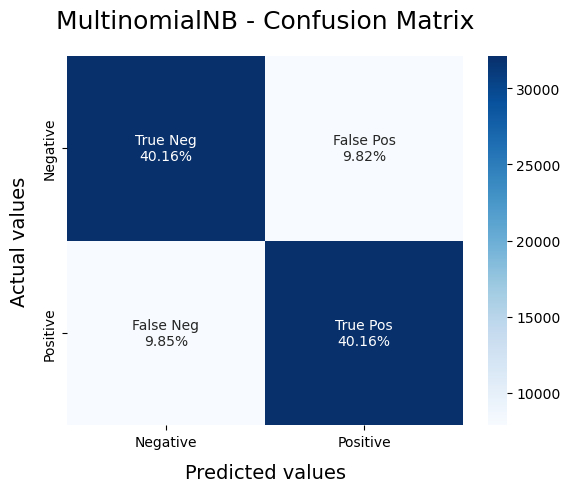

In [36]:
from sklearn.naive_bayes import MultinomialNB

NBmodel = MultinomialNB()
NBmodel.fit(X_train, y_train)

train_accuracy = NBmodel.score(X_train, y_train)
test_accuracy = NBmodel.score(X_test, y_test)

print('MultinomialNB Results')
print('----------------------')
print('Training accuracy:', round(train_accuracy * 100, 2), '%')
print('Test accuracy:', round(test_accuracy * 100, 2), '%')

model_Evaluate(NBmodel, X_test, y_test)

# **Training and Evaluating the SGDClassifier Model**

The following steps outline the process of **training and evaluating the SGDClassifier model** using the dataset:

SGDClassifier Results
----------------------
Training accuracy: 77.39 %
Test accuracy: 77.37 %

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.79      0.78     39986
           4       0.78      0.76      0.77     40014

    accuracy                           0.77     80000
   macro avg       0.77      0.77      0.77     80000
weighted avg       0.77      0.77      0.77     80000



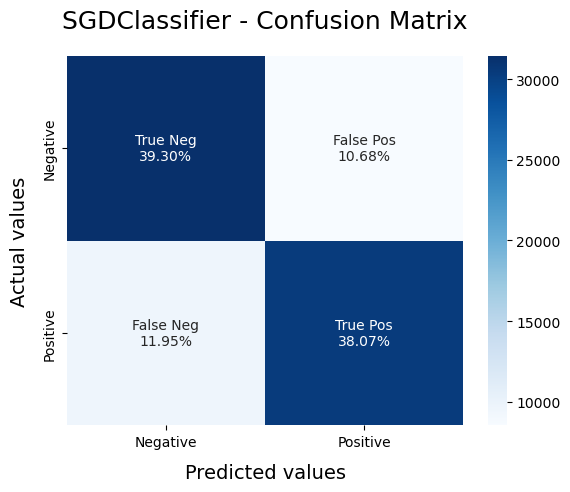

In [37]:
from sklearn.linear_model import SGDClassifier

SGDmodel = SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)
SGDmodel.fit(X_train, y_train)

train_accuracy = SGDmodel.score(X_train, y_train)
test_accuracy = SGDmodel.score(X_test, y_test)

print('SGDClassifier Results')
print('----------------------')
print('Training accuracy:', round(train_accuracy * 100, 2), '%')
print('Test accuracy:', round(test_accuracy * 100, 2), '%')

model_Evaluate(SGDmodel, X_test, y_test)

# **Comparative Analysis of All Models**

For better understanding, the confusion matrices are visualised side by side. It also clearly shows the comparison between all the models.

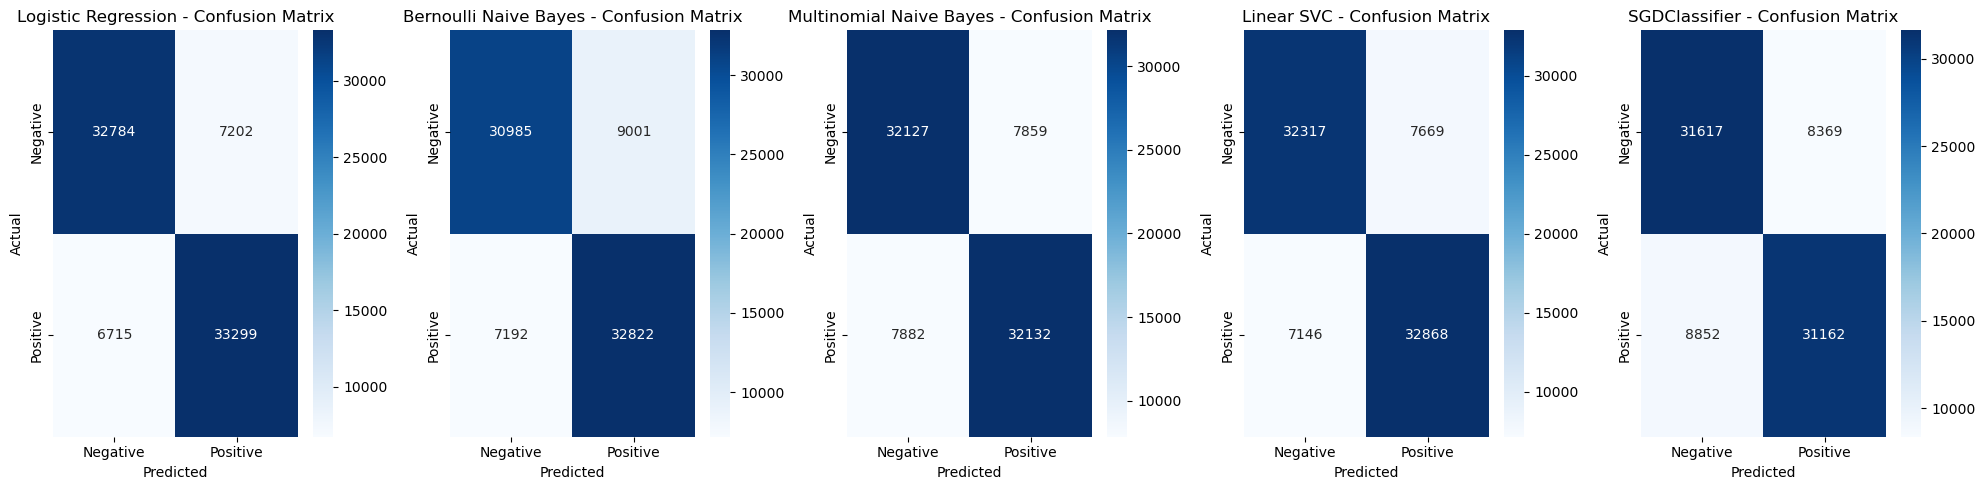

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier

# All models to evaluate
models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ('Bernoulli Naive Bayes', BernoulliNB()),
    ('Multinomial Naive Bayes', MultinomialNB()),
    ('Linear SVC', LinearSVC(max_iter=1000)),
    ('SGDClassifier', SGDClassifier(max_iter=1000))
]

# Categories for confusion matrix
categories = ['Negative', 'Positive']

# Set plot
fig, axes = plt.subplots(1, 5, figsize=(20, 5))  # Create a 1-row, 5-column subplot grid

# Train and evaluate each model
for i, (model_name, model) in enumerate(models):
    model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = model.predict(X_test)

    # Generate confusion matrix
    cf_matrix = confusion_matrix(y_test, y_pred)

    # Plot each confusion matrix on the corresponding subplot
    sns.heatmap(cf_matrix, annot=True, cmap='Blues', fmt='g', xticklabels=categories, yticklabels=categories, ax=axes[i])
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    axes[i].set_title(f'{model_name} - Confusion Matrix')

#for better spacing
plt.tight_layout()
plt.show()

# **Saving Trained Models and Vectoriser**

### **Objective:**  
Persist **trained models** and the **TF-IDF vectoriser** for future use without retraining.

### **Tools Used:**  
- Python’s `pickle` module for **object serialisation**.

### **Components Saved:**  
- `vectoriser.pickle` → Stores the **fitted TF-IDF vectoriser**.  
- `Sentiment-LR.pickle` → **Logistic Regression** model.  
- `Sentiment-BNB.pickle` → **Bernoulli Naive Bayes** model.  
- `Sentiment-MNB.pickle` → **Multinomial Naive Bayes** model.  
- `Sentiment-SVC.pickle` → **Linear SVC** model.  
- `Sentiment-SGD.pickle` → **SGDClassifier** model.  

### **Purpose:**  
- Enables **quick loading and prediction** without repeating the training process.  
- Useful for **deployment** or further analysis.  

In [39]:
import pickle

# Save the vectoriser
with open('vectoriser.pickle', 'wb') as file:
    pickle.dump(vectoriser, file)

# Save Logistic Regression model
with open('Sentiment-LR.pickle', 'wb') as file:
    pickle.dump(LRmodel, file)

# Save BernoulliNB model
with open('Sentiment-BNB.pickle', 'wb') as file:
    pickle.dump(BNBmodel, file)

# Save MultinomialNB model
with open('Sentiment-MNB.pickle', 'wb') as file:
    pickle.dump(NBmodel, file)

# Save LinearSVC model
with open('Sentiment-SVC.pickle', 'wb') as file:
    pickle.dump(SVCmodel, file)

# Save SGDClassifier model
with open('Sentiment-SGD.pickle', 'wb') as file:
    pickle.dump(SGDmodel, file)

# **Sentiment Prediction using Saved Model and Vectoriser**

### **Components:**  
- **Pickle:** Used to **load the pre-trained TF-IDF vectoriser** and **Logistic Regression model**.  
- **Preprocessing:** Basic **text normalisation** (e.g., lowercasing).

### **Prediction Process:**  
1. **Transforms the input text** using the vectoriser.  
2. **Applies the Logistic Regression model** to classify sentiment.  
    
### **Demo:**  
Predicts sentiment for a list of sample tweets:  
- `"I hate Twitter"` → **Negative**  
- `"May the Force be with you."` → **Positive**  
- `"I like her"` → **Positive**  
- `"This is an amazing tool!"` → **Positive**  

### **User Interaction:**  
- Accepts **user input** in real-time.  
- Outputs whether the entered text expresses **Positive** or **Negative** sentiment.

### **Purpose:**  
- Demonstrates **real-world usage** of trained NLP models.  
- Enables **quick testing and deployment** without retraining.  

In [41]:
import pickle

# Preprocessing function to clean the text data
def preprocess(text):
    return [t.lower() for t in text]

# Load the vectoriser.
with open('vectoriser.pickle', 'rb') as file:
    vectoriser = pickle.load(file)

# Load the LR Model.
with open('Sentiment-LR.pickle', 'rb') as file:
    LRmodel = pickle.load(file)

# Example predictions to display
example_tweets = [
    "I like twitter",
    "May the Force be with you.",
    "I hate him",
    "This Product is Shit"
]

print("Example Tweet Sentiment Predictions:")
print("=" * 30)

# Print example tweet predictions
for tweet in example_tweets:
    textdata = vectoriser.transform(preprocess([tweet]))
    sentiment = LRmodel.predict(textdata)
    if sentiment[0] == 0:
        result = "Negative"
    else:
        result = "Positive"

    print(f"Tweet: '{tweet}' ⟶ Sentiment: {result}")

print("=" * 30)

# Ask the user for input text
user_input = input("Please enter your text for sentiment analysis: ")

# Preprocess the text and transform it using the vectoriser
textdata = vectoriser.transform(preprocess([user_input]))

# Predict the sentiment
sentiment = LRmodel.predict(textdata)

# Display the result
if sentiment[0] == 0:
    result = "Negative"
else:
    result = "Positive"

print(f"Text: '{user_input}' ⟶ Sentiment: {result}")

Example Tweet Sentiment Predictions:
Tweet: 'I like twitter' ⟶ Sentiment: Positive
Tweet: 'May the Force be with you.' ⟶ Sentiment: Positive
Tweet: 'I hate him' ⟶ Sentiment: Negative
Tweet: 'This Product is Shit' ⟶ Sentiment: Negative


Please enter your text for sentiment analysis:  I love reading books.


Text: 'I love reading books.' ⟶ Sentiment: Positive
